In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

Using device:  cuda


In [2]:
# -----------------------------
# Imports
# -----------------------------
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# -----------------------------
# Data Augmentation (ResNet paper style)
# -----------------------------
# Paper:
# - pad 4 pixels on each side
# - random 32x32 crop
# - random horizontal flip
# - normalize
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Testing: only normalize original image
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# -----------------------------
# Load CIFAR-10
# -----------------------------
full_trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# -----------------------------
# Paper-style split: 45k / 5k
# -----------------------------
train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_trainset,
    [train_size, val_size]
)

# Validation should not use augmentation
val_dataset.dataset.transform = test_transform

# -----------------------------
# Data Loaders
# -----------------------------
batch_size = 128   # paper batch size

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train samples :", len(train_dataset))
print("Val samples   :", len(val_dataset))
print("Test samples  :", len(testset))

100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


Train samples : 45000
Val samples   : 5000
Test samples  : 10000


In [3]:
import torch
import torch.nn as nn

# -----------------------------
# Basic Residual Block
# -----------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out


# -----------------------------
# Custom ResNet-18
# -----------------------------
class CustomResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomResNet18, self).__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3, 16, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # Total 18 layers
        self.layer1 = self._make_layer(16, 2, stride=1)
        self.layer2 = self._make_layer(32, 2, stride=2)
        self.layer3 = self._make_layer(64, 2, stride=2)
        self.layer4 = self._make_layer(64, 2, stride=1)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            BasicBlock(self.in_channels, out_channels, stride)
        )
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(self.in_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)
        return x

In [4]:
import torch.optim as optim

model = CustomResNet18().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[91, 136],
    gamma=0.1
)

num_epochs = 182

In [5]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"In Millions          : {total_params/1e6:.3f} M")

Total Parameters     : 323,226
Trainable Parameters : 323,226
In Millions          : 0.323 M


In [6]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy": [],
    "Validation Loss": [],
    "Validation Accuracy": [],
    "Learning Rate": []
}


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(loader), 100 * correct / total


def train_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return total_loss / len(train_loader), 100 * correct / total


for epoch in range(1, num_epochs + 1):

    train_loss, train_acc = train_epoch()
    val_loss, val_acc = evaluate(val_loader)

    current_lr = optimizer.param_groups[0]["lr"]

    history["Epoch"].append(epoch)
    history["Train Loss"].append(train_loss)
    history["Train Accuracy"].append(train_acc)
    history["Validation Loss"].append(val_loss)
    history["Validation Accuracy"].append(val_acc)
    history["Learning Rate"].append(current_lr)

    print(
        f"Epoch {epoch:3d}/{num_epochs} | "
        f"LR: {current_lr:.4f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    scheduler.step()


# Save Excel
df = pd.DataFrame(history)
df.to_excel("custom_resnet18_cifar10_results.xlsx", index=False)


# Final test
test_loss, test_acc = evaluate(test_loader)

print("\nFinal Test Results")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Error   : {100-test_acc:.2f}%")

Epoch   1/182 | LR: 0.1000 | Train Loss: 1.6585 | Train Acc: 37.89% | Val Loss: 1.3880 | Val Acc: 48.80%
Epoch   2/182 | LR: 0.1000 | Train Loss: 1.1473 | Train Acc: 58.30% | Val Loss: 1.0173 | Val Acc: 64.20%
Epoch   3/182 | LR: 0.1000 | Train Loss: 0.8945 | Train Acc: 68.05% | Val Loss: 0.8430 | Val Acc: 70.02%
Epoch   4/182 | LR: 0.1000 | Train Loss: 0.7197 | Train Acc: 74.59% | Val Loss: 0.6746 | Val Acc: 76.40%
Epoch   5/182 | LR: 0.1000 | Train Loss: 0.6145 | Train Acc: 78.67% | Val Loss: 0.6887 | Val Acc: 75.22%
Epoch   6/182 | LR: 0.1000 | Train Loss: 0.5275 | Train Acc: 81.42% | Val Loss: 0.6445 | Val Acc: 77.88%
Epoch   7/182 | LR: 0.1000 | Train Loss: 0.4682 | Train Acc: 83.64% | Val Loss: 0.5743 | Val Acc: 79.14%
Epoch   8/182 | LR: 0.1000 | Train Loss: 0.4163 | Train Acc: 85.43% | Val Loss: 0.5708 | Val Acc: 80.50%
Epoch   9/182 | LR: 0.1000 | Train Loss: 0.3710 | Train Acc: 87.00% | Val Loss: 0.5947 | Val Acc: 78.80%
Epoch  10/182 | LR: 0.1000 | Train Loss: 0.3446 | Train

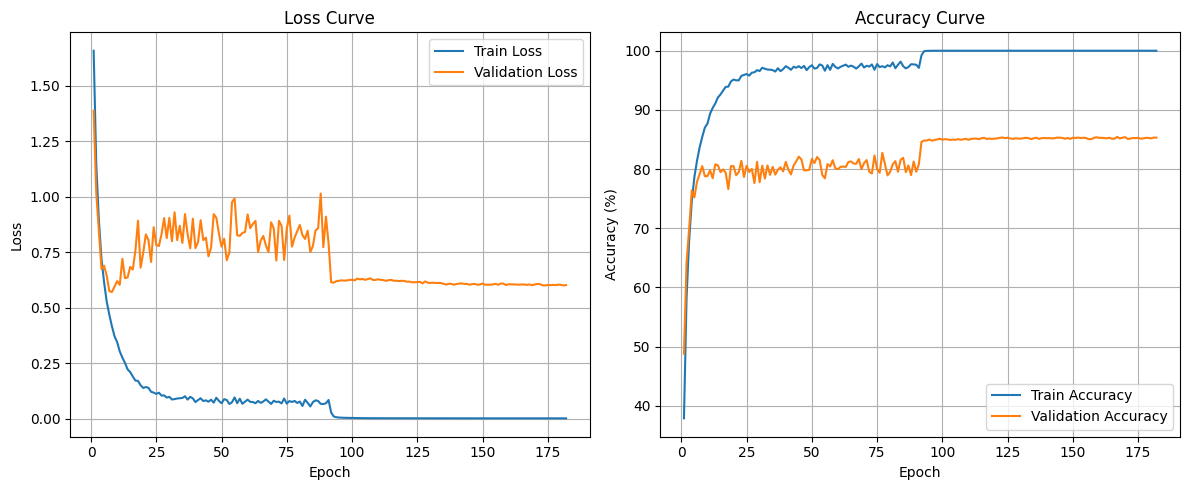

In [8]:
epochs = history["Epoch"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["Train Loss"], label="Train Loss")
plt.plot(epochs, history["Validation Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["Train Accuracy"], label="Train Accuracy")
plt.plot(epochs, history["Validation Accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()